In [ ]:
import re
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np


# During Training Stats

baseline: 15 validation epochs found
λ=1: 15 validation epochs found
λ=100: 15 validation epochs found
λ=250: 15 validation epochs found
λ=500: 15 validation epochs found
λ=1000: 15 validation epochs found


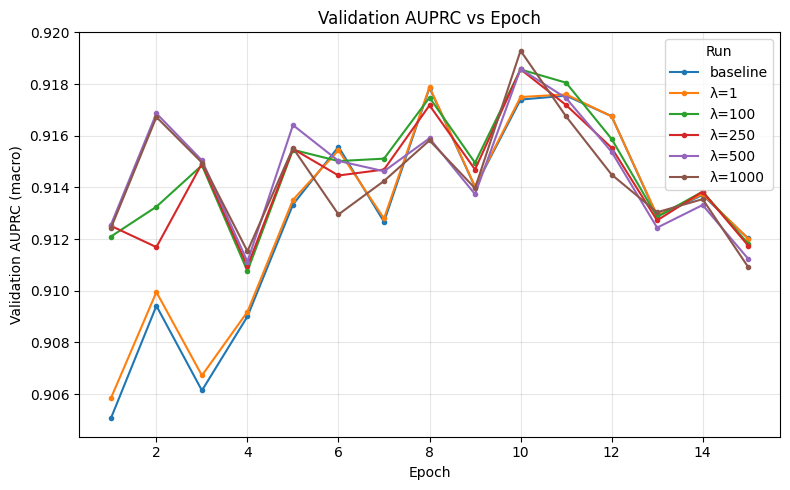

Saved auprc_vs_epoch.png


In [ ]:
#GENERATED CODE
#comparing each run's validation auprc per epoch

# --- Config: edit these paths and labels ---
log_files = {
    "baseline": r"C:\Users\noors\University\thesis\ecg-thesis\outputs\finetuned-finetuned-eval\logs\ex2baseline_ecg_15ep_24254459.out",
    "λ=1":      r"C:\Users\noors\University\thesis\ecg-thesis\outputs\finetuned-finetuned-eval\logs\ex2L1_ecg_15ep_24254469.out",
    "λ=100":    r"C:\Users\noors\University\thesis\ecg-thesis\outputs\finetuned-finetuned-eval\logs\ex2L100_ecg_15ep_24254477.out",
    "λ=250":    r"C:\Users\noors\University\thesis\ecg-thesis\outputs\finetuned-finetuned-eval\logs\ex2L250_ecg_15ep_24254488.out",
    "λ=500":    r"C:\Users\noors\University\thesis\ecg-thesis\outputs\finetuned-finetuned-eval\logs\ex2L500_ecg_15ep_24254495.out",
    "λ=1000":   r"C:\Users\noors\University\thesis\ecg-thesis\outputs\finetuned-finetuned-eval\logs\ex2L1000_ecg_15ep_24254499.out",
}

def parse_valid_lines(filepath):
    """
    Read a log file and extract (epoch, auprc) from every validation line.
    Validation lines contain '[valid]' and 'epoch NNN'.
    """
    epochs = []
    auprcs = []

    with open(filepath, "r") as f:
        for line in f:
            # Only process validation summary lines
            if "[valid]" not in line:
                continue

            # Extract epoch number from e.g. "epoch 001 | valid on..."
            epoch_match = re.search(r"epoch (\d+)", line)
            if not epoch_match:
                continue
            epoch = int(epoch_match.group(1))

            # Extract auprc=VALUE from the key=value fields
            auprc_match = re.search(r"\bauprc=([0-9.]+)", line)
            if not auprc_match:
                continue
            auprc = float(auprc_match.group(1))

            epochs.append(epoch)
            auprcs.append(auprc)

    return epochs, auprcs


# --- Parse all runs ---
results = {}
for label, path in log_files.items():
    epochs, auprcs = parse_valid_lines(path)
    results[label] = (epochs, auprcs)
    print(f"{label}: {len(epochs)} validation epochs found")


# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

for label, (epochs, auprcs) in results.items():
    ax.plot(epochs, auprcs, marker="o", markersize=3, label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation AUPRC (macro)")
ax.set_title("Validation AUPRC vs Epoch")
ax.legend(title="Run")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("auprc_vs_epoch.png", dpi=150)
plt.show()
print("Saved auprc_vs_epoch.png")

baseline: 15 training epochs found
λ=1: 15 training epochs found
λ=100: 15 training epochs found
λ=250: 15 training epochs found
λ=500: 15 training epochs found
λ=1000: 15 training epochs found


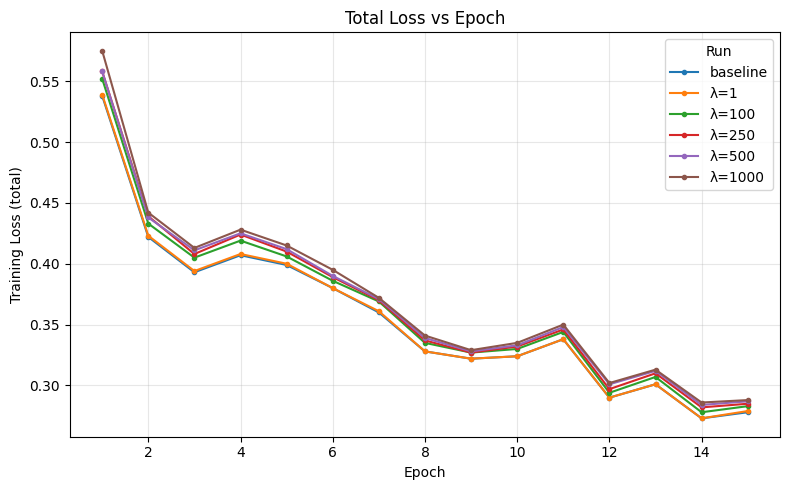

Saved total_loss_vs_epoch.png


In [ ]:
#GENERATED CODE
#total loss per run per epoch

def parse_train_lines(filepath):
    """
    Read a log file and extract per-epoch training metrics.
    We only want the LAST step of each epoch (e.g. '200 / 200').
    Returns a dict of lists: epochs, loss, bce_loss, kg_weighted, kg_violation_rate
    """
    epochs = []
    losses = []
    bce_losses = []
    kg_weighted_losses = []
    kg_violation_rates = []

    with open(filepath, "r") as f:
        for line in f:
            # Only process training step lines
            if "[train_inner]" not in line:
                continue

            # Only keep the last step of each epoch: "200 / 200"
            # The pattern is "NNN / NNN" where both numbers match
            step_match = re.search(r"(\d+) / (\d+)", line)
            if not step_match:
                continue
            current_step = int(step_match.group(1))
            total_steps = int(step_match.group(2))
            if current_step != total_steps:
                continue

            # Extract epoch number
            epoch_match = re.search(r"epoch (\d+)", line)
            if not epoch_match:
                continue
            epoch = int(epoch_match.group(1))

            # Extract each metric
            loss_match = re.search(r"\bloss=([0-9.]+)", line)
            bce_match = re.search(r"\bbce_loss=([0-9.]+)", line)
            kg_w_match = re.search(r"\bkg_weighted=([0-9.]+)", line)
            kg_vr_match = re.search(r"\bkg_violation_rate=([0-9.]+)", line)

            # Skip line if any field is missing
            if not all([loss_match, bce_match, kg_w_match, kg_vr_match]):
                continue

            epochs.append(epoch)
            losses.append(float(loss_match.group(1)))
            bce_losses.append(float(bce_match.group(1)))
            kg_weighted_losses.append(float(kg_w_match.group(1)))
            kg_violation_rates.append(float(kg_vr_match.group(1)))

    return {
        "epochs": epochs,
        "loss": losses,
        "bce_loss": bce_losses,
        "kg_weighted": kg_weighted_losses,
        "kg_violation_rate": kg_violation_rates,
    }


# --- Parse all runs ---
train_results = {}
for label, path in log_files.items():
    data = parse_train_lines(path)
    train_results[label] = data
    print(f"{label}: {len(data['epochs'])} training epochs found")


# --- Plot: Total Loss vs Epoch ---
fig, ax = plt.subplots(figsize=(8, 5))

for label, data in train_results.items():
    ax.plot(data["epochs"], data["loss"], marker="o", markersize=3, label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss (total)")
ax.set_title("Total Loss vs Epoch")
ax.legend(title="Run")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("total_loss_vs_epoch.png", dpi=150)
plt.show()
print("Saved total_loss_vs_epoch.png")

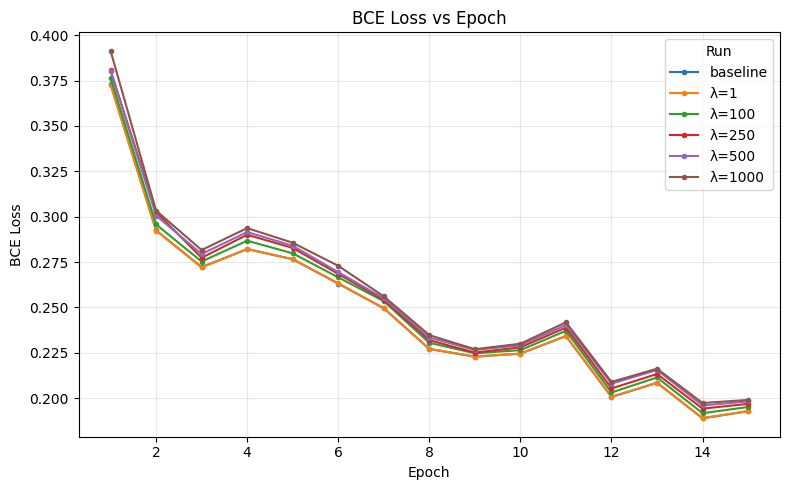

Saved bce_loss_vs_epoch.png


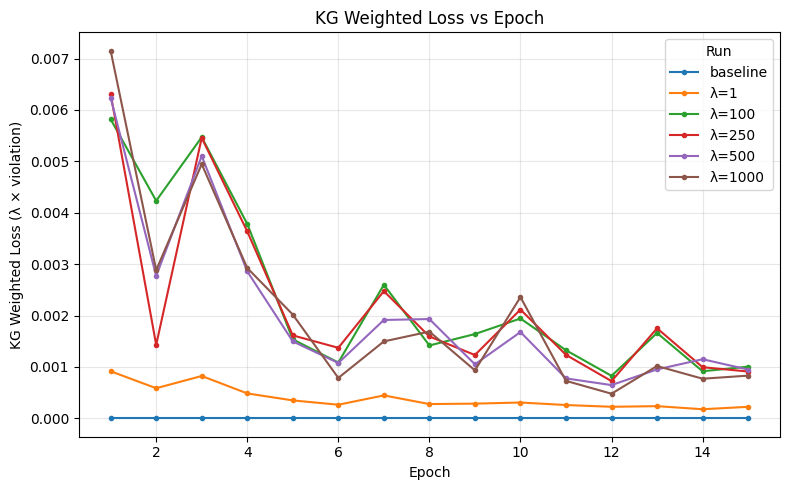

Saved kg_loss_vs_epoch.png


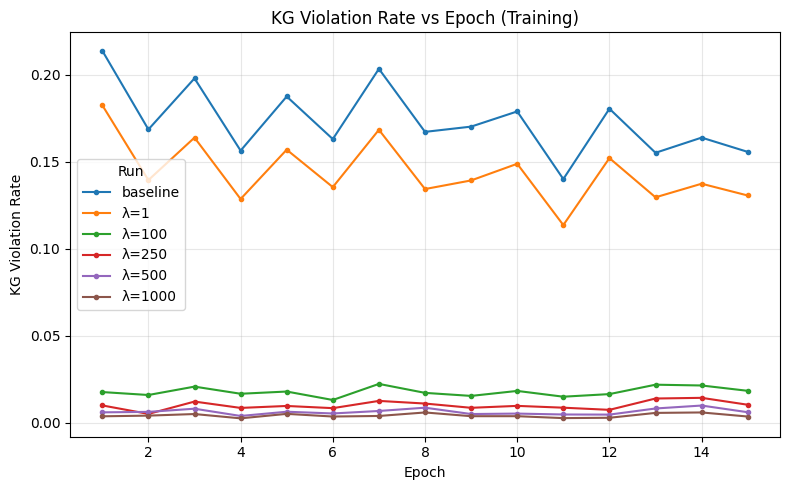

Saved kg_violation_rate_vs_epoch.png


In [ ]:
#GENERATED CODE
#BCE loss per run per epoch
fig, ax = plt.subplots(figsize=(8, 5))

for label, data in train_results.items():
    ax.plot(data["epochs"], data["bce_loss"], marker="o", markersize=3, label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("BCE Loss vs Epoch")
ax.legend(title="Run")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bce_loss_vs_epoch.png", dpi=150)
plt.show()
print("Saved bce_loss_vs_epoch.png")


#KG weighted loss per run per epoch 
fig, ax = plt.subplots(figsize=(8, 5))

for label, data in train_results.items():
    ax.plot(data["epochs"], data["kg_weighted"], marker="o", markersize=3, label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("KG Weighted Loss (λ × violation)")
ax.set_title("KG Weighted Loss vs Epoch")
ax.legend(title="Run")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kg_loss_vs_epoch.png", dpi=150)
plt.show()
print("Saved kg_loss_vs_epoch.png")


#KG violation rate per run per epoch
fig, ax = plt.subplots(figsize=(8, 5))

for label, data in train_results.items():
    ax.plot(data["epochs"], data["kg_violation_rate"], marker="o", markersize=3, label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("KG Violation Rate")
ax.set_title("KG Violation Rate vs Epoch (Training)")
ax.legend(title="Run")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kg_violation_rate_vs_epoch.png", dpi=150)
plt.show()
print("Saved kg_violation_rate_vs_epoch.png")

# Post Training Stats

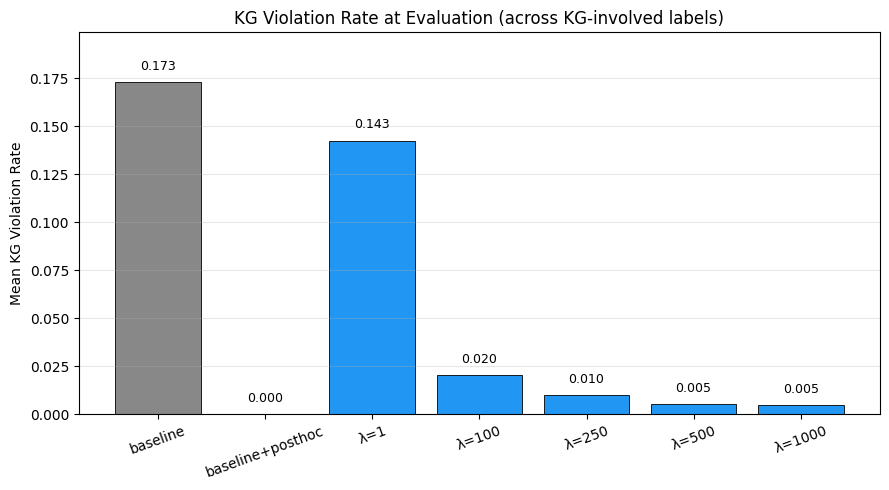

Saved kg_violation_rate_bar.png


In [ ]:
#GENERATED CODE
#KG violation rate per experiment

EVAL_DIR = r"C:\Users\noors\University\thesis\ecg-thesis\outputs\finetuned-finetuned-eval\eval"

runs = {
    "baseline":         "results_baseline.csv",
    "baseline+posthoc": "results_baseline_posthoc.csv",
    "λ=1":              "results_L1.csv",
    "λ=100":            "results_L100.csv",
    "λ=250":            "results_L250.csv",
    "λ=500":            "results_L500.csv",
    "λ=1000":           "results_L1000.csv",
}

# --- Load mean KG violation rate per run ---
# only labels involved in KG edges have a value; average those, skip NaN
violation_rates = {}
for run_label, filename in runs.items():
    df = pd.read_csv(os.path.join(EVAL_DIR, filename), index_col=0)
    df = df.drop(index="MACRO_AVG", errors="ignore")
    mean_rate = df["kg_violation_rate"].dropna().mean()
    violation_rates[run_label] = mean_rate

run_names = list(violation_rates.keys())
rates = [violation_rates[r] for r in run_names]

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#888888", "#444444"] + ["#2196F3"] * 5  # grey for baseline runs, blue for λ runs
bars = ax.bar(run_names, rates, color=colors, edgecolor="black", linewidth=0.6)

# annotate each bar with its value
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{rate:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Mean KG Violation Rate")
ax.set_title("KG Violation Rate at Evaluation (across KG-involved labels)")
ax.set_ylim(0, max(rates) * 1.15)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout() 
plt.savefig("kg_violation_rate_bar.png", dpi=150)
plt.show()
print("Saved kg_violation_rate_bar.png")

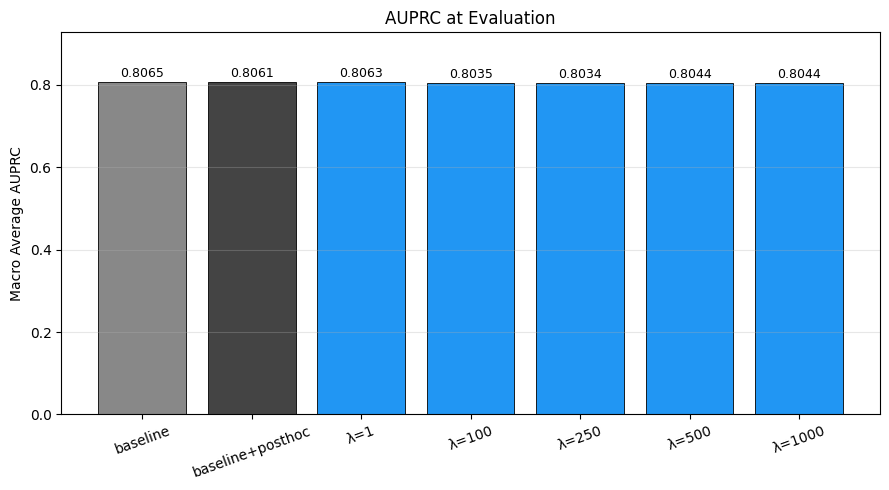

Saved auprc_bar.png


In [ ]:
#GENERATED CODE
#AUPRC value per run
EVAL_DIR = r"C:\Users\noors\University\thesis\ecg-thesis\outputs\finetuned-finetuned-eval\eval"

runs = {
    "baseline":         "results_baseline.csv",
    "baseline+posthoc": "results_baseline_posthoc.csv",
    "λ=1":              "results_L1.csv",
    "λ=100":            "results_L100.csv",
    "λ=250":            "results_L250.csv",
    "λ=500":            "results_L500.csv",
    "λ=1000":           "results_L1000.csv",
}

# --- Load MACRO avg AUPRC rate per run ---
auprc_values = {}
for run_label, filename in runs.items():
    df = pd.read_csv(os.path.join(EVAL_DIR, filename), index_col=0)
    macro_auprc = df.loc["MACRO_AVG", "AUPRC"]
    auprc_values[run_label] = macro_auprc 

run_names = list(auprc_values.keys())
auprcs = [auprc_values[r] for r in run_names]

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#888888", "#444444"] + ["#2196F3"] * 5  # grey for baseline runs, blue for λ runs
bars = ax.bar(run_names, auprcs, color=colors, edgecolor="black", linewidth=0.6)

# annotate each bar with its value
for bar, rate in zip(bars, auprcs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{rate:.4f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Macro Average AUPRC")
ax.set_title("AUPRC at Evaluation")
ax.set_ylim(0, max(auprcs) * 1.15)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout() 
plt.savefig("auprc_bar.png", dpi=150)
plt.show()
print("Saved auprc_bar.png")

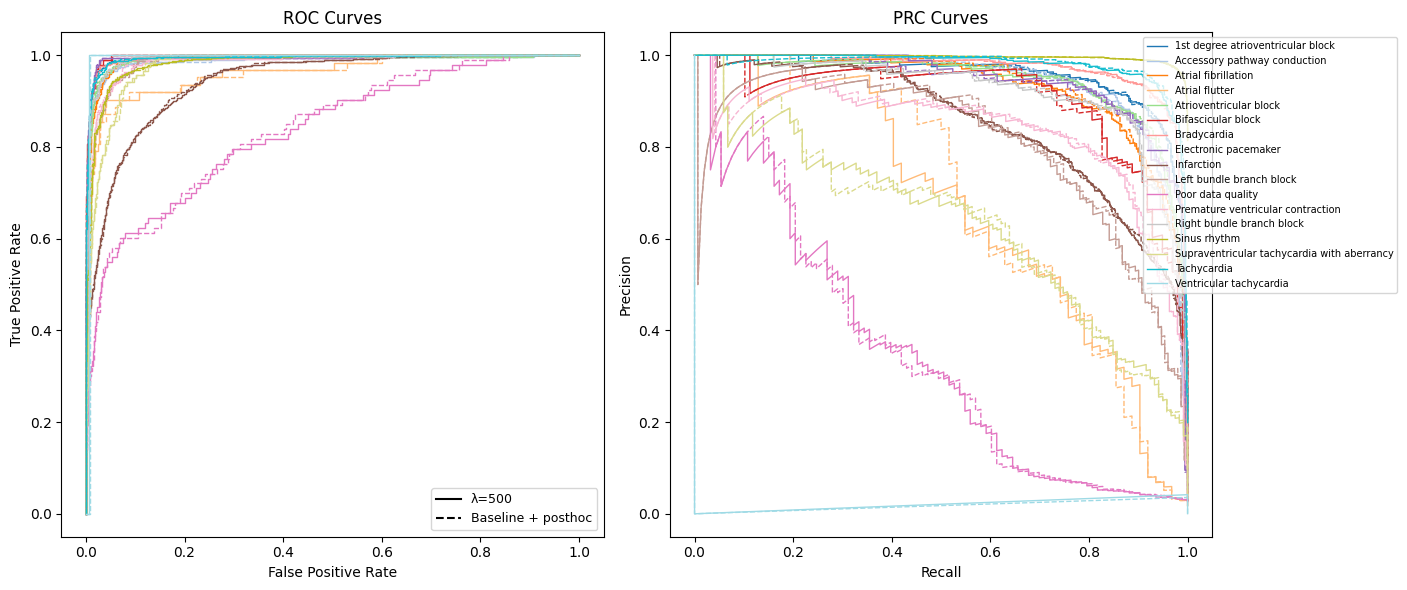

In [ ]:
#GENERATED CODE
#ROC and PRC curves for each label
EVAL_DIR = r"C:\Users\noors\University\thesis\ecg-thesis\outputs\finetuned-finetuned-eval\eval"

data_L500    = np.load(os.path.join(EVAL_DIR, "curves_L500.npz"))
data_posthoc = np.load(os.path.join(EVAL_DIR, "curves_baseline_posthoc.npz"))

# get label names from keys
label_names = sorted(set(k.split("__")[0] for k in data_L500.files))

colors = plt.cm.tab20(np.linspace(0, 1, len(label_names)))

fig, (ax_roc, ax_prc) = plt.subplots(1, 2, figsize=(14, 6))

for i, label in enumerate(label_names):
    color = colors[i]
    
    # ROC
    ax_roc.plot(data_L500[f"{label}__fpr"],    data_L500[f"{label}__tpr"],    color=color, linestyle="-",  linewidth=1.0)
    ax_roc.plot(data_posthoc[f"{label}__fpr"], data_posthoc[f"{label}__tpr"], color=color, linestyle="--", linewidth=1.0)
    
    # PRC
    ax_prc.plot(data_L500[f"{label}__recall"],    data_L500[f"{label}__precision"],    color=color, linestyle="-",  linewidth=1.0, label=label)
    ax_prc.plot(data_posthoc[f"{label}__recall"], data_posthoc[f"{label}__precision"], color=color, linestyle="--", linewidth=1.0)

# axis labels and titles
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves")

ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.set_title("PRC Curves")

# legend for labels (from PRC since that's where label= is set)
ax_prc.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.35, 1))

# separate legend for line styles
from matplotlib.lines import Line2D
style_legend = [
    Line2D([0], [0], color="black", linestyle="-",  label="λ=500"),
    Line2D([0], [0], color="black", linestyle="--", label="Baseline + posthoc"),
]
ax_roc.legend(handles=style_legend, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("roc_prc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()